In [1]:
import numpy as np
from scipy.fft import rfft, rfftfreq

def a_weighting(fs, n_fft):
    """Calculates A-weighting coefficients for each frequency bin."""
    freqs = rfftfreq(n_fft, 1/fs)
    # Avoid log of zero at 0Hz
    f = np.where(freqs == 0, 1e-10, freqs)
    
    # Standard IEC 61672-1:2003 A-weighting formula
    f1 = 20.602
    f2 = 107.652
    f3 = 737.862
    f4 = 12194.217
    a1000 = -2.000 # Normalization factor to ensure 1kHz = 0dB
    
    num = (12194.217**2) * (f**4)
    den = ((f**2 + f1**2) * np.sqrt((f**2 + f2**2) * (f**2 + f3**2)) * (f**2 + f4**2))
    
    # Calculate weight in dB
    ra_f = 20 * np.log10(num / den) - a1000
    return ra_f

# 1. Setup Simulation (Substitute with your 'sd.rec' data)
fs = 44100
t = np.linspace(0, 1, fs) # 1 second recording
# Signal: A loud 100Hz tone and a quiet 1kHz tone
signal = 0.5 * np.sin(2 * np.pi * 100 * t) + 0.1 * np.sin(2 * np.pi * 1000 * t)

# 2. Perform FFT (Real-valued FFT for efficiency)
n = len(signal)
fft_data = rfft(signal)
# Normalize magnitude so 1.0 peak in time = 1.0 peak in frequency
magnitudes = np.abs(fft_data) * (2 / n) 

# 3. Get A-weighting curve
weights_db = a_weighting(fs, n)

# 4. Apply weighting
# Convert magnitudes to dB, add weights, then convert back to linear power
# Using 1.0 as the digital reference (dBFS)
mags_db = 20 * np.log10(magnitudes + 1e-12) # +1e-12 to avoid log(0)
a_weighted_mags_db = mags_db + weights_db

# 5. Calculate Overall Level
# Summing power (squared pressure) is the correct way to get 'total' sound level
total_power = np.sum(10**(a_weighted_mags_db / 10))
total_db_a = 10 * np.log10(total_power)

print(f"Overall Level: {total_db_a:.2f} dBFS(A)")

Overall Level: -18.85 dBFS(A)


In [2]:
from scipy.stats import qmc
import pandas as pd

# Define bounds [min, max] for each variable
bounds = {
    'A': (10, 30),
    'B': (0.5, 1.5),
    'C': (100, 200),
    'D': (5, 20),
}

n_runs = 20  # number of experiments

sampler = qmc.LatinHypercube(d=len(bounds))
sample = sampler.random(n=n_runs)

# Scale to actual variable ranges
l_bounds = [v[0] for v in bounds.values()]
u_bounds = [v[1] for v in bounds.values()]
scaled = qmc.scale(sample, l_bounds, u_bounds)

df = pd.DataFrame(scaled, columns=bounds.keys())
print(df)

            A         B           C          D
0   10.100345  1.123601  161.586432   6.819967
1   13.290168  1.365540  158.871290  13.513082
2   20.451986  0.551125  175.753488  11.093369
3   14.914152  0.812883  106.068712   8.405143
4   26.598230  1.473581  168.245033  13.209893
5   28.152147  0.748106  149.811432  15.851551
6   25.013005  0.501102  171.567523  12.450670
7   23.800555  1.265418  140.998122  18.170483
8   29.154958  0.761147  130.608260  14.952474
9   22.344973  1.312429  196.220672   9.171936
10  17.651810  0.903100  119.375661   9.638530
11  24.213570  1.229336  184.228132  18.675447
12  27.915352  1.044874  126.103814  19.911694
13  15.897892  0.873765  193.636289   6.049201
14  12.765643  1.165404  122.375610   7.503097
15  11.123169  1.432495  153.229788   5.269679
16  19.004363  0.976536  114.760580  10.945779
17  18.399132  0.640075  102.679415  17.329675
18  21.010541  0.671129  185.053545  16.598274
19  16.760524  1.067607  138.327084  14.415644


In [2]:
import matplotlib.pyplot as plt
import numpy as np

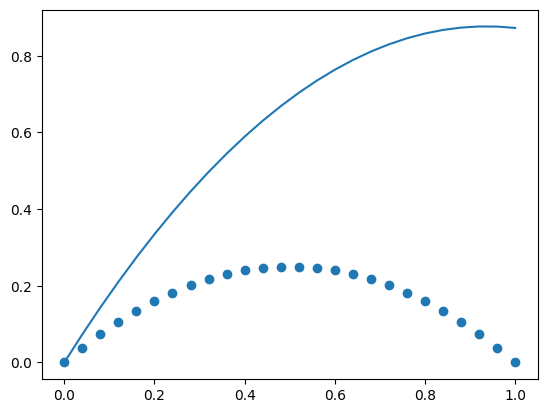

In [8]:
r_hub = 0.015
r_tip = 0.040
step = 0.001
r = np.arange(r_hub,r_tip+step, step)
r_norm = (r-r_hub)/(r_tip-r_hub)

weighting = 1
straight_angle = 50

y = (r_norm * (1.0 - r_norm))**weighting + np.deg2rad(straight_angle)*r_norm

plt.plot(r_norm, y)
plt.scatter(r_norm, (r_norm * (1.0 - r_norm))**weighting)
plt.show()